[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/notes/notebooks/03-arbol-vs-random-forest-regresion.ipynb)


# Comparativo: Árbol de Decisión vs Random Forest para Regresión

## ¿Cuál de los dos modelos predice mejor?

En este notebook compararemos de forma justa:

1. **Decision Tree Regressor**
2. **Random Forest Regressor**

Ambos utilizarán:

- el mismo dataset real;
- la misma división Train/Test;
- la misma validación cruzada;
- las mismas métricas;
- optimización independiente de hiperparámetros;
- las mismas observaciones de Test.

### Métrica principal
Usaremos **RMSE** como criterio principal.

También analizaremos:

- MAE
- MedAE
- MSE
- R²
- MAPE
- Train vs Test
- Validación cruzada
- Real vs Predicho
- Residuos
- Márgenes de error
- Errores por observación
- Tiempo de búsqueda

> El mejor modelo será el mejor **para este dataset y este protocolo**, no necesariamente para todos los problemas de regresión.



# 1. Diferencia conceptual

## Árbol de Decisión

Utiliza un único árbol compuesto por reglas.

### Ventajas
- fácil de interpretar;
- rápido;
- permite visualizar reglas.

### Desventajas
- puede ser inestable;
- puede sobreajustarse;
- tiene alta varianza.

## Random Forest

Combina muchos árboles construidos con bootstrap y aleatoriedad de variables.

### Ventajas
- mayor estabilidad;
- menor varianza;
- suele generalizar mejor.

### Desventajas
- menos interpretable;
- mayor coste computacional.



# 2. Dataset real

Usaremos `load_diabetes` de scikit-learn:

- 442 observaciones;
- 10 variables predictoras;
- objetivo numérico.

Usaremos el mismo dataset de los dos Colabs anteriores para que la comparación sea directa.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_diabetes
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:

diabetes = load_diabetes(as_frame=True, scaled=False)

X = diabetes.data.copy()
y = diabetes.target.copy()

df = X.copy()
df["target"] = y

print("Dimensiones:", df.shape)
display(df.head())


Dimensiones: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


# 3. Exploración rápida

In [3]:

print("Valores faltantes:")
display(df.isna().sum().to_frame("faltantes"))

print("\nResumen estadístico:")
display(df.describe().T)


Valores faltantes:


,faltantes
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0



Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
age,442.0,48.518100,13.109028,19.0000,38.2500,50.00000,59.0000,79.000
sex,442.0,1.468326,0.499561,1.0000,1.0000,1.00000,2.0000,2.000
bmi,442.0,26.375792,4.418122,18.0000,23.2000,25.70000,29.2750,42.200
bp,442.0,94.647014,13.831283,62.0000,84.0000,93.00000,105.0000,133.000
s1,442.0,189.140271,34.608052,97.0000,164.2500,186.00000,209.7500,301.000
s2,442.0,115.439140,30.413081,41.6000,96.0500,113.00000,134.5000,242.400
s3,442.0,49.788462,12.934202,22.0000,40.2500,48.00000,57.7500,99.000
s4,442.0,4.070249,1.290450,2.0000,3.0000,4.00000,5.0000,9.090
s5,442.0,4.641411,0.522391,3.2581,4.2767,4.62005,4.9972,6.107
s6,442.0,91.260181,11.496335,58.0000,83.2500,91.00000,98.0000,124.000


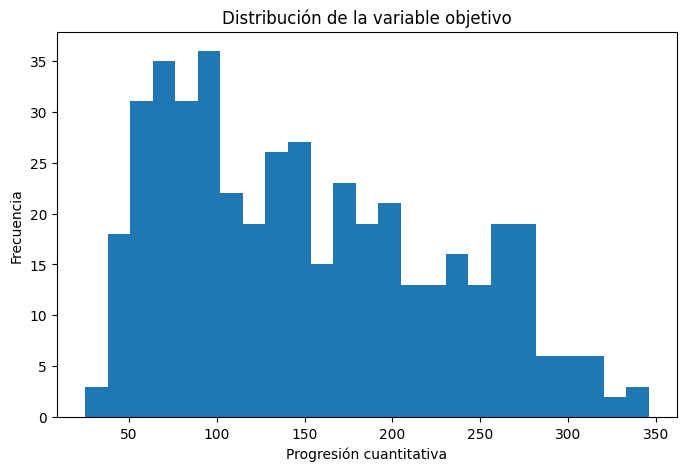

In [4]:

plt.figure(figsize=(8,5))
plt.hist(y, bins=25)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Progresión cuantitativa")
plt.ylabel("Frecuencia")
plt.show()



# 4. Train/Test

Ambos modelos deben recibir exactamente las mismas observaciones.

- 80% Train
- 20% Test


In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (353, 10)
Test : (89, 10)


# 5. Métricas comunes

In [6]:

def metricas_regresion(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100
    }



## Interpretación

- **MAE:** error absoluto promedio. Menor es mejor.
- **MedAE:** mediana del error absoluto. Menor es mejor.
- **MSE:** error cuadrático medio. Menor es mejor.
- **RMSE:** penaliza más los errores grandes. Menor es mejor.
- **R²:** proporción relativa de variabilidad explicada. Mayor es mejor.
- **MAPE:** error porcentual medio. Menor es mejor.


# 6. Validación cruzada común

In [7]:

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# 7. Optimización del Árbol de Decisión

In [8]:

arbol = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

param_grid_arbol = {
    "criterion": ["squared_error", "absolute_error"],
    "max_depth": [2, 4, 6, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5, 10]
}

inicio = time.perf_counter()

grid_arbol = GridSearchCV(
    estimator=arbol,
    param_grid=param_grid_arbol,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_arbol.fit(X_train, y_train)

tiempo_arbol = time.perf_counter() - inicio
mejor_arbol = grid_arbol.best_estimator_

print("Mejores hiperparámetros:")
print(grid_arbol.best_params_)

print("\nMejor RMSE promedio de CV:")
print(round(-grid_arbol.best_score_, 3))

print("\nTiempo de búsqueda:")
print(round(tiempo_arbol, 3), "segundos")


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 112, in start_daemon
RuntimeError: Failed to start artifact tool daemon (exited early)


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 112, in start_daemon
RuntimeError: Failed to start artifact tool daemon (exited early)
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/sprea

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 776, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 93, in _populate_warmup_workbook
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/generated/interface/models.py", line 30086, in autofit_columns
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/client.py", line 135, in call
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/client.py", line 115, in _recv_one_line
artifact_tool.rpc.client.TransportError: RPC co

Mejores hiperparámetros:
{'criterion': 'squared_error', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Mejor RMSE promedio de CV:
63.048

Tiempo de búsqueda:
6.431 segundos


# 8. Optimización de Random Forest

In [9]:

rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [4, None],
    "min_samples_leaf": [1, 4],
    "max_features": ["sqrt", 1.0]
}

inicio = time.perf_counter()

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)

tiempo_rf = time.perf_counter() - inicio
mejor_rf = grid_rf.best_estimator_

print("Mejores hiperparámetros:")
print(grid_rf.best_params_)

print("\nMejor RMSE promedio de CV:")
print(round(-grid_rf.best_score_, 3))

print("\nTiempo de búsqueda:")
print(round(tiempo_rf, 3), "segundos")


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/generated/interface/models.py", line 32317, in hydrate_crdt_from_proto
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.

Mejores hiperparámetros:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 100}

Mejor RMSE promedio de CV:
57.238

Tiempo de búsqueda:
7.911 segundos



# 9. Evaluación final sobre Train y Test

Ahora ambos modelos optimizados se evalúan con exactamente el mismo Test.


In [10]:

pred_arbol_train = mejor_arbol.predict(X_train)
pred_arbol_test = mejor_arbol.predict(X_test)

pred_rf_train = mejor_rf.predict(X_train)
pred_rf_test = mejor_rf.predict(X_test)

met_arbol_train = metricas_regresion(y_train, pred_arbol_train)
met_arbol_test = metricas_regresion(y_test, pred_arbol_test)

met_rf_train = metricas_regresion(y_train, pred_rf_train)
met_rf_test = metricas_regresion(y_test, pred_rf_test)

tabla_test = pd.DataFrame({
    "Árbol de Decisión": met_arbol_test,
    "Random Forest": met_rf_test
}).T

display(tabla_test.round(3))


,MAE,MedAE,MSE,RMSE,R2,MAPE_%
Árbol de Decisión,49.365,40.559,3735.500,61.119,0.295,45.553
Random Forest,43.083,37.607,2789.059,52.812,0.474,39.363


# 10. ¿Quién gana en cada métrica?

In [11]:

ganadores = pd.DataFrame({
    "Métrica": ["MAE", "MedAE", "MSE", "RMSE", "R²", "MAPE"],
    "Mejor modelo": [
        tabla_test["MAE"].idxmin(),
        tabla_test["MedAE"].idxmin(),
        tabla_test["MSE"].idxmin(),
        tabla_test["RMSE"].idxmin(),
        tabla_test["R2"].idxmax(),
        tabla_test["MAPE_%"].idxmin()
    ]
})

display(ganadores)


,Métrica,Mejor modelo
0,MAE,Random Forest
1,MedAE,Random Forest
2,MSE,Random Forest
3,RMSE,Random Forest
4,R²,Random Forest
5,MAPE,Random Forest


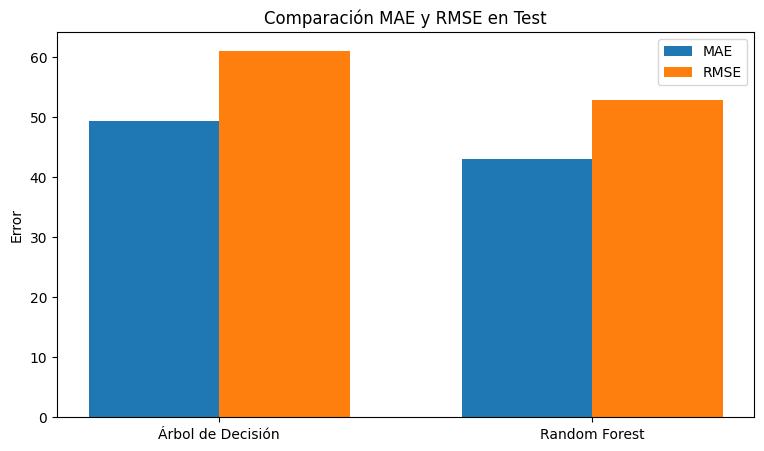

In [12]:

# Gráfico MAE y RMSE
x = np.arange(2)
ancho = 0.35

modelos = ["Árbol de Decisión", "Random Forest"]
mae_vals = [met_arbol_test["MAE"], met_rf_test["MAE"]]
rmse_vals = [met_arbol_test["RMSE"], met_rf_test["RMSE"]]

plt.figure(figsize=(9,5))
plt.bar(x-ancho/2, mae_vals, width=ancho, label="MAE")
plt.bar(x+ancho/2, rmse_vals, width=ancho, label="RMSE")
plt.xticks(x, modelos)
plt.ylabel("Error")
plt.title("Comparación MAE y RMSE en Test")
plt.legend()
plt.show()


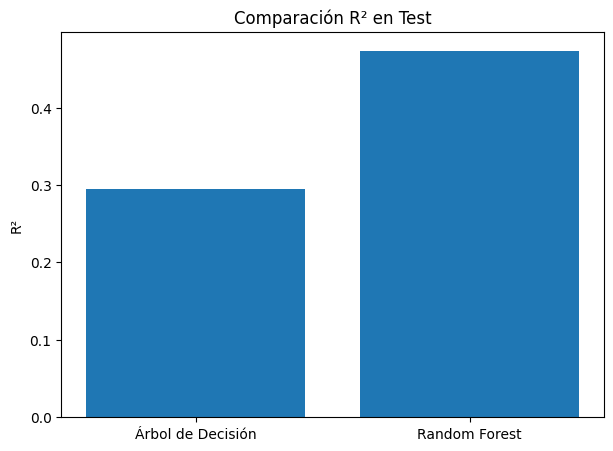

In [13]:

plt.figure(figsize=(7,5))
plt.bar(
    ["Árbol de Decisión", "Random Forest"],
    [met_arbol_test["R2"], met_rf_test["R2"]]
)
plt.ylabel("R²")
plt.title("Comparación R² en Test")
plt.show()


# 11. Train vs Test: análisis de sobreajuste

In [14]:

comparacion_train_test = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "Random Forest"],
    "RMSE Train": [
        met_arbol_train["RMSE"],
        met_rf_train["RMSE"]
    ],
    "RMSE Test": [
        met_arbol_test["RMSE"],
        met_rf_test["RMSE"]
    ],
    "R2 Train": [
        met_arbol_train["R2"],
        met_rf_train["R2"]
    ],
    "R2 Test": [
        met_arbol_test["R2"],
        met_rf_test["R2"]
    ]
})

display(comparacion_train_test.round(3))


,Modelo,RMSE Train,RMSE Test,R2 Train,R2 Test
0,Árbol de Decisión,57.954,61.119,0.447,0.295
1,Random Forest,38.723,52.812,0.753,0.474


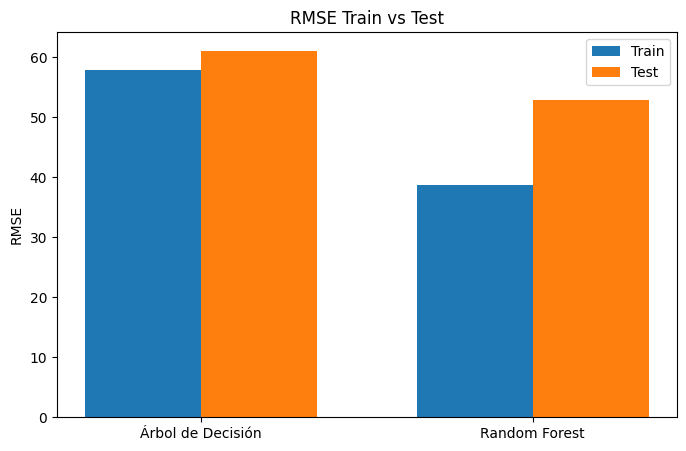

In [15]:

x = np.arange(2)
ancho = 0.35

plt.figure(figsize=(8,5))
plt.bar(
    x-ancho/2,
    comparacion_train_test["RMSE Train"],
    width=ancho,
    label="Train"
)
plt.bar(
    x+ancho/2,
    comparacion_train_test["RMSE Test"],
    width=ancho,
    label="Test"
)
plt.xticks(x, comparacion_train_test["Modelo"])
plt.ylabel("RMSE")
plt.title("RMSE Train vs Test")
plt.legend()
plt.show()



Una diferencia muy grande entre Train y Test puede indicar sobreajuste.

Random Forest suele reducir la varianza respecto a un árbol individual, pero también puede sobreajustar si no se controla.


# 12. Validación cruzada de los modelos optimizados

In [16]:

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_arbol = cross_validate(
    mejor_arbol,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_rf = cross_validate(
    mejor_rf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

tabla_cv = pd.DataFrame({
    "Árbol_RMSE": -cv_arbol["test_RMSE"],
    "RF_RMSE": -cv_rf["test_RMSE"],
    "Árbol_MAE": -cv_arbol["test_MAE"],
    "RF_MAE": -cv_rf["test_MAE"],
    "Árbol_R2": cv_arbol["test_R2"],
    "RF_R2": cv_rf["test_R2"]
})

display(tabla_cv.round(3))


,Árbol_RMSE,RF_RMSE,Árbol_MAE,RF_MAE,Árbol_R2,RF_R2
0,60.433,54.576,47.917,45.452,0.321,0.446
1,68.682,61.773,58.481,54.700,0.322,0.451
2,61.902,53.433,49.794,43.849,0.198,0.402
3,60.156,56.178,50.189,47.171,0.379,0.459
4,64.066,60.231,51.666,48.422,0.408,0.477


In [17]:

resumen_cv = pd.DataFrame({
    "Árbol de Decisión": {
        "CV_MAE_promedio": (-cv_arbol["test_MAE"]).mean(),
        "CV_RMSE_promedio": (-cv_arbol["test_RMSE"]).mean(),
        "CV_R2_promedio": cv_arbol["test_R2"].mean(),
        "CV_RMSE_sd": (-cv_arbol["test_RMSE"]).std(ddof=1)
    },
    "Random Forest": {
        "CV_MAE_promedio": (-cv_rf["test_MAE"]).mean(),
        "CV_RMSE_promedio": (-cv_rf["test_RMSE"]).mean(),
        "CV_R2_promedio": cv_rf["test_R2"].mean(),
        "CV_RMSE_sd": (-cv_rf["test_RMSE"]).std(ddof=1)
    }
}).T

display(resumen_cv.round(3))


,CV_MAE_promedio,CV_RMSE_promedio,CV_R2_promedio,CV_RMSE_sd
Árbol de Decisión,51.609,63.048,0.326,3.510
Random Forest,47.919,57.238,0.447,3.613


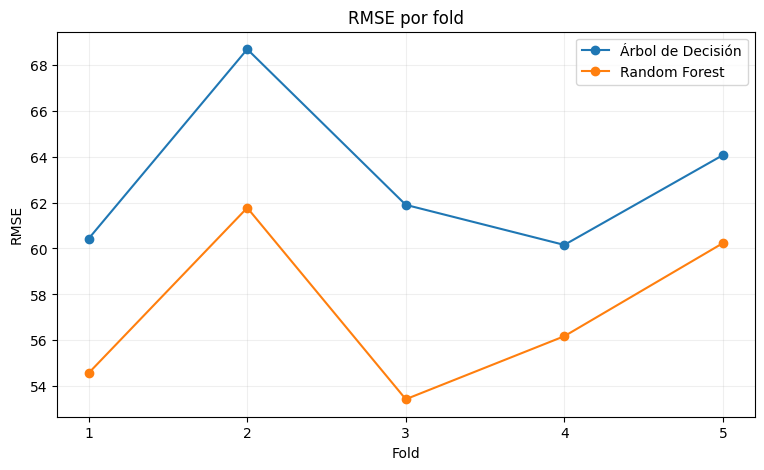

In [18]:

folds = np.arange(1, 6)

plt.figure(figsize=(9,5))
plt.plot(
    folds,
    -cv_arbol["test_RMSE"],
    marker="o",
    label="Árbol de Decisión"
)
plt.plot(
    folds,
    -cv_rf["test_RMSE"],
    marker="o",
    label="Random Forest"
)
plt.xticks(folds)
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("RMSE por fold")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# 13. Comparación observación por observación

In [19]:

predicciones = pd.DataFrame({
    "Real": y_test.to_numpy(),
    "Árbol": pred_arbol_test,
    "Random Forest": pred_rf_test
})

predicciones["ErrorAbs_Árbol"] = np.abs(
    predicciones["Real"] - predicciones["Árbol"]
)

predicciones["ErrorAbs_RF"] = np.abs(
    predicciones["Real"] - predicciones["Random Forest"]
)

predicciones["Mejor_en_caso"] = np.where(
    predicciones["ErrorAbs_Árbol"] < predicciones["ErrorAbs_RF"],
    "Árbol de Decisión",
    np.where(
        predicciones["ErrorAbs_RF"] < predicciones["ErrorAbs_Árbol"],
        "Random Forest",
        "Empate"
    )
)

display(predicciones.head(15).round(2))


,Real,Árbol,Random Forest,ErrorAbs_Árbol,ErrorAbs_RF,Mejor_en_caso
0,219.0,164.67,149.22,54.33,69.78,Árbol de Decisión
1,70.0,191.10,164.96,121.10,94.96,Random Forest
2,202.0,164.67,152.06,37.33,49.94,Árbol de Decisión
3,230.0,191.10,256.57,38.90,26.57,Random Forest
4,111.0,100.56,131.34,10.44,20.34,Árbol de Decisión
5,84.0,100.56,101.71,16.56,17.71,Árbol de Decisión
6,242.0,271.08,221.78,29.08,20.22,Random Forest
7,272.0,191.10,195.21,80.90,76.79,Random Forest
8,94.0,164.67,134.48,70.67,40.48,Random Forest
9,96.0,191.10,170.75,95.10,74.75,Random Forest


,Número de observaciones
Mejor_en_caso,
Random Forest,49
Árbol de Decisión,40


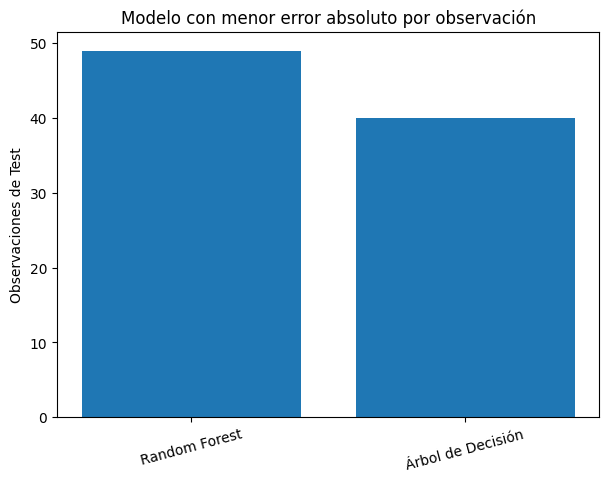

In [20]:

conteo_casos = predicciones["Mejor_en_caso"].value_counts()

display(conteo_casos.to_frame("Número de observaciones"))

plt.figure(figsize=(7,5))
plt.bar(conteo_casos.index, conteo_casos.values)
plt.ylabel("Observaciones de Test")
plt.title("Modelo con menor error absoluto por observación")
plt.xticks(rotation=15)
plt.show()


# 14. Real vs Predicho

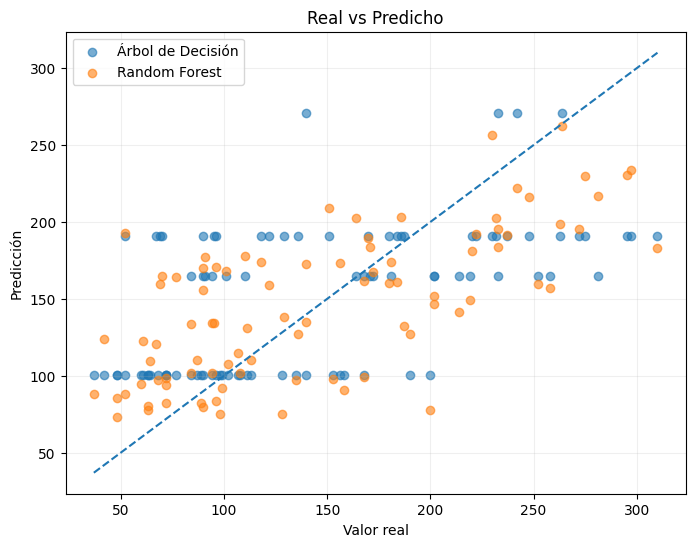

In [21]:

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_arbol_test,
    alpha=0.6,
    label="Árbol de Decisión"
)

plt.scatter(
    y_test,
    pred_rf_test,
    alpha=0.6,
    label="Random Forest"
)

minimo = min(
    y_test.min(),
    pred_arbol_test.min(),
    pred_rf_test.min()
)

maximo = max(
    y_test.max(),
    pred_arbol_test.max(),
    pred_rf_test.max()
)

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Real vs Predicho")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# 15. Residuos

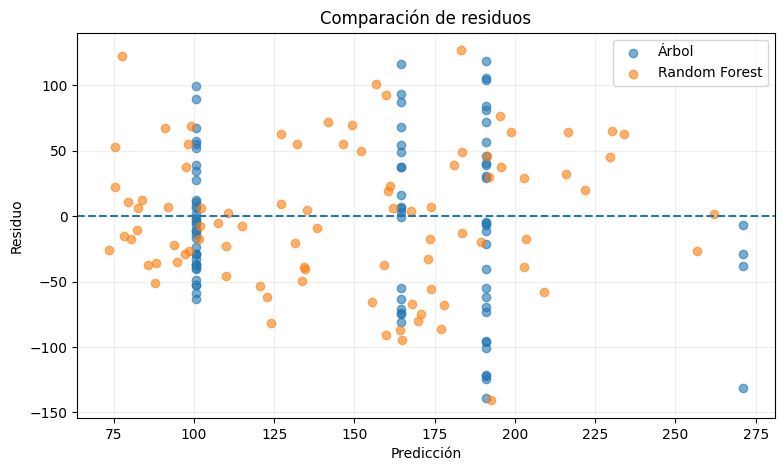

In [22]:

residuos_arbol = y_test.to_numpy() - pred_arbol_test
residuos_rf = y_test.to_numpy() - pred_rf_test

plt.figure(figsize=(9,5))
plt.scatter(
    pred_arbol_test,
    residuos_arbol,
    alpha=0.6,
    label="Árbol"
)
plt.scatter(
    pred_rf_test,
    residuos_rf,
    alpha=0.6,
    label="Random Forest"
)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Comparación de residuos")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# 16. Márgenes de error

In [23]:

def tolerancias(y_real, y_pred):
    ape = (
        np.abs(np.asarray(y_real) - np.asarray(y_pred))
        / np.abs(np.asarray(y_real))
        * 100
    )
    return {
        "≤ 10%": np.mean(ape <= 10) * 100,
        "≤ 20%": np.mean(ape <= 20) * 100,
        "≤ 30%": np.mean(ape <= 30) * 100
    }

tabla_tolerancias = pd.DataFrame({
    "Árbol de Decisión": tolerancias(y_test, pred_arbol_test),
    "Random Forest": tolerancias(y_test, pred_rf_test)
})

display(tabla_tolerancias.round(2))


,Árbol de Decisión,Random Forest
≤ 10%,20.22,19.10
≤ 20%,37.08,37.08
≤ 30%,48.31,56.18


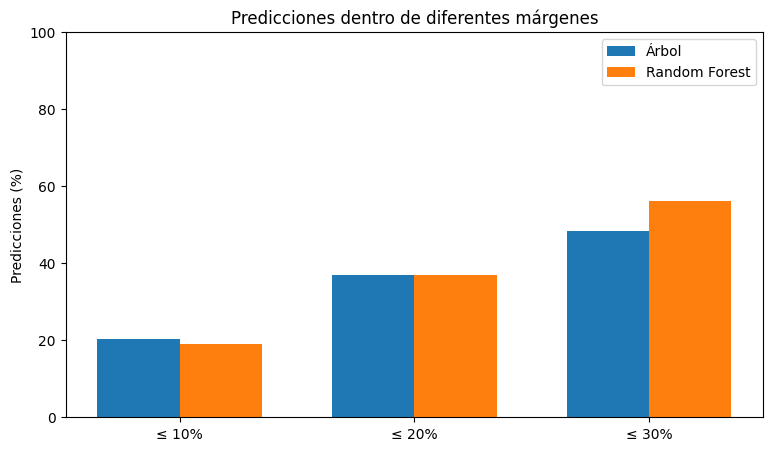

In [24]:

margenes = list(tabla_tolerancias.index)
x = np.arange(len(margenes))
ancho = 0.35

plt.figure(figsize=(9,5))
plt.bar(
    x-ancho/2,
    tabla_tolerancias["Árbol de Decisión"],
    width=ancho,
    label="Árbol"
)
plt.bar(
    x+ancho/2,
    tabla_tolerancias["Random Forest"],
    width=ancho,
    label="Random Forest"
)
plt.xticks(x, margenes)
plt.ylim(0,100)
plt.ylabel("Predicciones (%)")
plt.title("Predicciones dentro de diferentes márgenes")
plt.legend()
plt.show()


# 17. Casos con errores grandes

In [25]:

errores_grandes = predicciones[
    [
        "Real",
        "Árbol",
        "Random Forest",
        "ErrorAbs_Árbol",
        "ErrorAbs_RF"
    ]
].copy()

errores_grandes["Mayor_error"] = errores_grandes[
    ["ErrorAbs_Árbol", "ErrorAbs_RF"]
].max(axis=1)

errores_grandes = errores_grandes.sort_values(
    "Mayor_error",
    ascending=False
)

display(errores_grandes.head(10).round(2))


,Real,Árbol,Random Forest,ErrorAbs_Árbol,ErrorAbs_RF,Mayor_error
61,52.0,191.10,192.70,139.10,140.70,140.70
30,140.0,271.08,172.79,131.08,32.79,131.08
20,310.0,191.10,183.16,118.90,126.84,126.84
15,67.0,191.10,120.61,124.10,53.61,124.10
46,200.0,100.56,77.67,99.44,122.33,122.33
52,69.0,191.10,159.94,122.10,90.94,122.10
1,70.0,191.10,164.96,121.10,94.96,121.10
72,281.0,164.67,216.60,116.33,64.40,116.33
13,297.0,191.10,233.93,105.90,63.07,105.90
16,295.0,191.10,230.27,103.90,64.73,103.90


# 18. Coste computacional

In [26]:

coste = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "Random Forest"],
    "Tiempo GridSearch (s)": [
        tiempo_arbol,
        tiempo_rf
    ],
    "Número de árboles": [
        1,
        mejor_rf.n_estimators
    ]
})

display(coste.round(3))


,Modelo,Tiempo GridSearch (s),Número de árboles
0,Árbol de Decisión,6.431,1
1,Random Forest,7.911,100



Un modelo puede predecir mejor pero ser más costoso.

Por eso la selección final también puede depender de:

- interpretabilidad;
- velocidad;
- memoria;
- facilidad de despliegue.


# 19. Selección automática según RMSE

In [27]:

ganador_rmse = (
    "Árbol de Decisión"
    if met_arbol_test["RMSE"] < met_rf_test["RMSE"]
    else "Random Forest"
)

rmse_mejor = min(
    met_arbol_test["RMSE"],
    met_rf_test["RMSE"]
)

rmse_peor = max(
    met_arbol_test["RMSE"],
    met_rf_test["RMSE"]
)

mejora_relativa = (
    (rmse_peor - rmse_mejor)
    / rmse_peor
    * 100
)

print("MEJOR MODELO SEGÚN RMSE EN TEST:", ganador_rmse)
print("Mejora relativa de RMSE:", round(mejora_relativa, 2), "%")

print("\n--- RESULTADOS TEST ---")

print("\nÁRBOL")
print("MAE :", round(met_arbol_test["MAE"], 3))
print("RMSE:", round(met_arbol_test["RMSE"], 3))
print("R²  :", round(met_arbol_test["R2"], 3))

print("\nRANDOM FOREST")
print("MAE :", round(met_rf_test["MAE"], 3))
print("RMSE:", round(met_rf_test["RMSE"], 3))
print("R²  :", round(met_rf_test["R2"], 3))


MEJOR MODELO SEGÚN RMSE EN TEST: Random Forest
Mejora relativa de RMSE: 13.59 %

--- RESULTADOS TEST ---

ÁRBOL
MAE : 49.365
RMSE: 61.119
R²  : 0.295

RANDOM FOREST
MAE : 43.083
RMSE: 52.812
R²  : 0.474



# 20. ¿Cómo decidir cuál es mejor?

## Para priorizar predicción

Preferimos el modelo que muestre:

- menor RMSE;
- menor MAE;
- mayor R²;
- validación cruzada más consistente;
- menor error en nuevas observaciones.

## Para priorizar interpretabilidad

Un Árbol de Decisión puede ser preferible incluso si pierde algo de precisión, porque sus reglas son mucho más fáciles de explicar.

## Para producción

Si la elección entre familias de modelos fuera crítica, convendría confirmar la decisión con:

- un conjunto holdout adicional;
- validación cruzada anidada;
- evaluación temporal si los datos tienen componente de tiempo.



# 21. Resumen conceptual

| Aspecto | Árbol de Decisión | Random Forest |
|---|---|---|
| Número de árboles | 1 | Muchos |
| Interpretabilidad | Muy alta | Media/Baja |
| Velocidad | Alta | Menor |
| Estabilidad | Menor | Mayor |
| Varianza | Mayor | Menor |
| Overfitting | Más probable | Generalmente menor |
| No linealidad | Sí | Sí |
| Interacciones | Sí | Sí |
| Feature importance | Sí | Sí |
| Predicción | Una hoja | Promedio de árboles |



# 22. Conclusión

La comparación correcta no consiste en afirmar que un algoritmo es siempre superior.

Debemos comparar ambos con:

**mismos datos + misma partición + mismas métricas + misma validación**

y después responder:

> **¿Cuál generaliza mejor en este problema?**

El notebook calcula automáticamente esa respuesta utilizando RMSE como criterio principal y muestra evidencia adicional con MAE, R², validación cruzada, residuos y errores por observación.
